2025-04-16 15:47:48.976569: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Carregando modelo de best_model_bce_dice_v3.keras...


2025-04-16 15:47:53.465333: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-16 15:47:57.017330: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-16 15:47:57.017444: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-16 15:47:57.018811: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-16 15:47:57.018911: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

Carregando conjunto de dados de teste...

Avaliando modelo no conjunto de teste...


I0000 00:00:1744818559.507426     133 service.cc:146] XLA service 0x7f8f9401d530 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744818559.507474     133 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-04-16 15:49:19.688734: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744818640.207265     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 201s 629ms/step - accuracy: 0.7424 - loss: 0.4902 - multiclass_iou: 0.0881 - precision: 0.7430 - recall: 0.6026

===== Métricas Gerais =====
Loss: 0.5022
Accuracy: 0.6963
Mean IoU: 0.0725
Precision: 0.6957
Recall: 0.5505

Processando métricas detalhadas incrementalmente...
Processando batch 1...
Processando batch 2...
Processando batch 3...
Processando batch 4...
Processando batch 5...
Processando batch 6...
Processando batch 7...
Processando batch 8...
Processando batch 9...
Processando batch 10...
Processando batch 11...
Processando batch 12...
Processando batch 13...
Processando batch 14...
Processando batch 15...
Processando batch 16...
Processando batch 17...
Processando batch 18...
Processando batch 19...
Processando batch 20...
Processando batch 21...
Processando batch 22...
Processando batch 23...
Processando batch 24...
Processando batch 25...
Processando batch 26...
Processando batch 27...
Processando batch 28...
Processando batch 29...
Processando 

2025-04-16 15:53:21.140921: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



===== Métricas Globais para o Artigo =====
IoU Global Médio: 0.0627
F1-Score Global: 0.0873
Precision Global: 0.1329
Recall Global: 0.0986

===== Verificação de Requisitos Mínimos =====
IoU Global Médio: 0.0627 (Mínimo aceitável: 0.75, Ideal: >0.85)
❌ IoU Global ABAIXO do mínimo aceitável
F1-Score Global: 0.0873 (Mínimo aceitável: 0.80, Ideal: >0.85)
❌ F1-Score Global ABAIXO do mínimo aceitável

===== Métricas por Classe =====
   Classe      IoU  Precision   Recall  F1-Score
 Classe_1 0.554325   0.821497 0.630237  0.713268
 Classe_2 0.000000   0.000000 0.000000  0.000000
 Classe_3 0.000000   0.000000 0.000000  0.000000
 Classe_4 0.000000   0.000000 0.000000  0.000000
 Classe_5 0.000000   0.000000 0.000000  0.000000
 Classe_6 0.000000   0.000000 0.000000  0.000000
 Classe_7 0.000000   0.000000 0.000000  0.000000
 Classe_8 0.000000   0.000000 0.000000  0.000000
 Classe_9 0.000000   0.000000 0.000000  0.000000
Classe_10 0.554126   0.557189 0.990178  0.713103
Classe_11 0.005542   0.006235

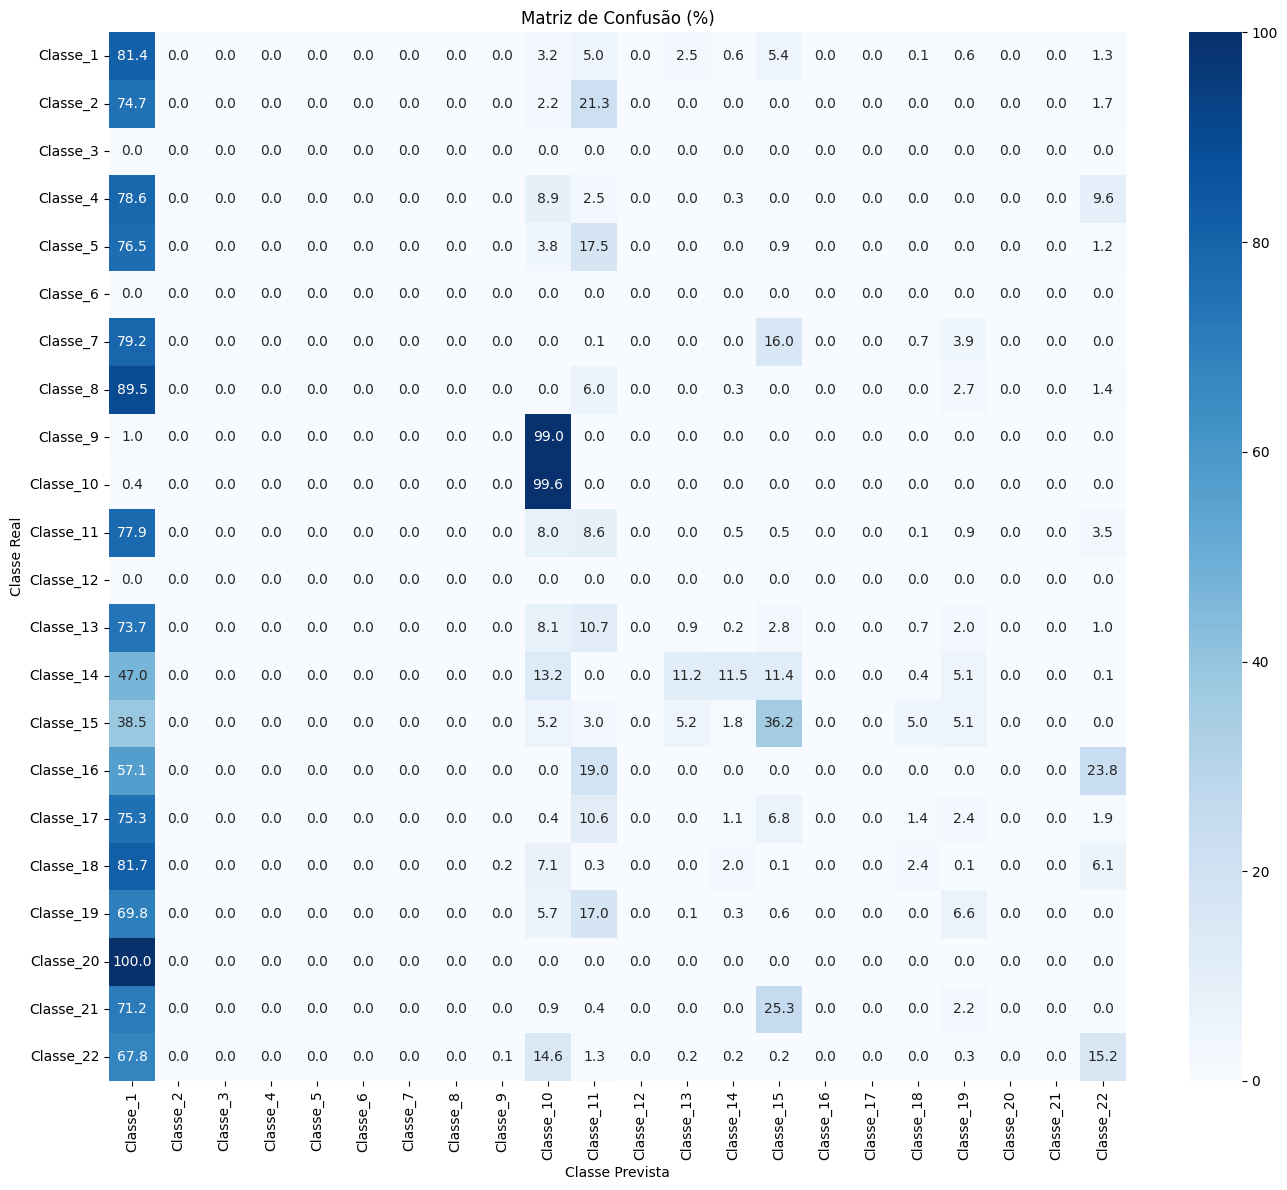


Gerando visualizações das métricas por classe...


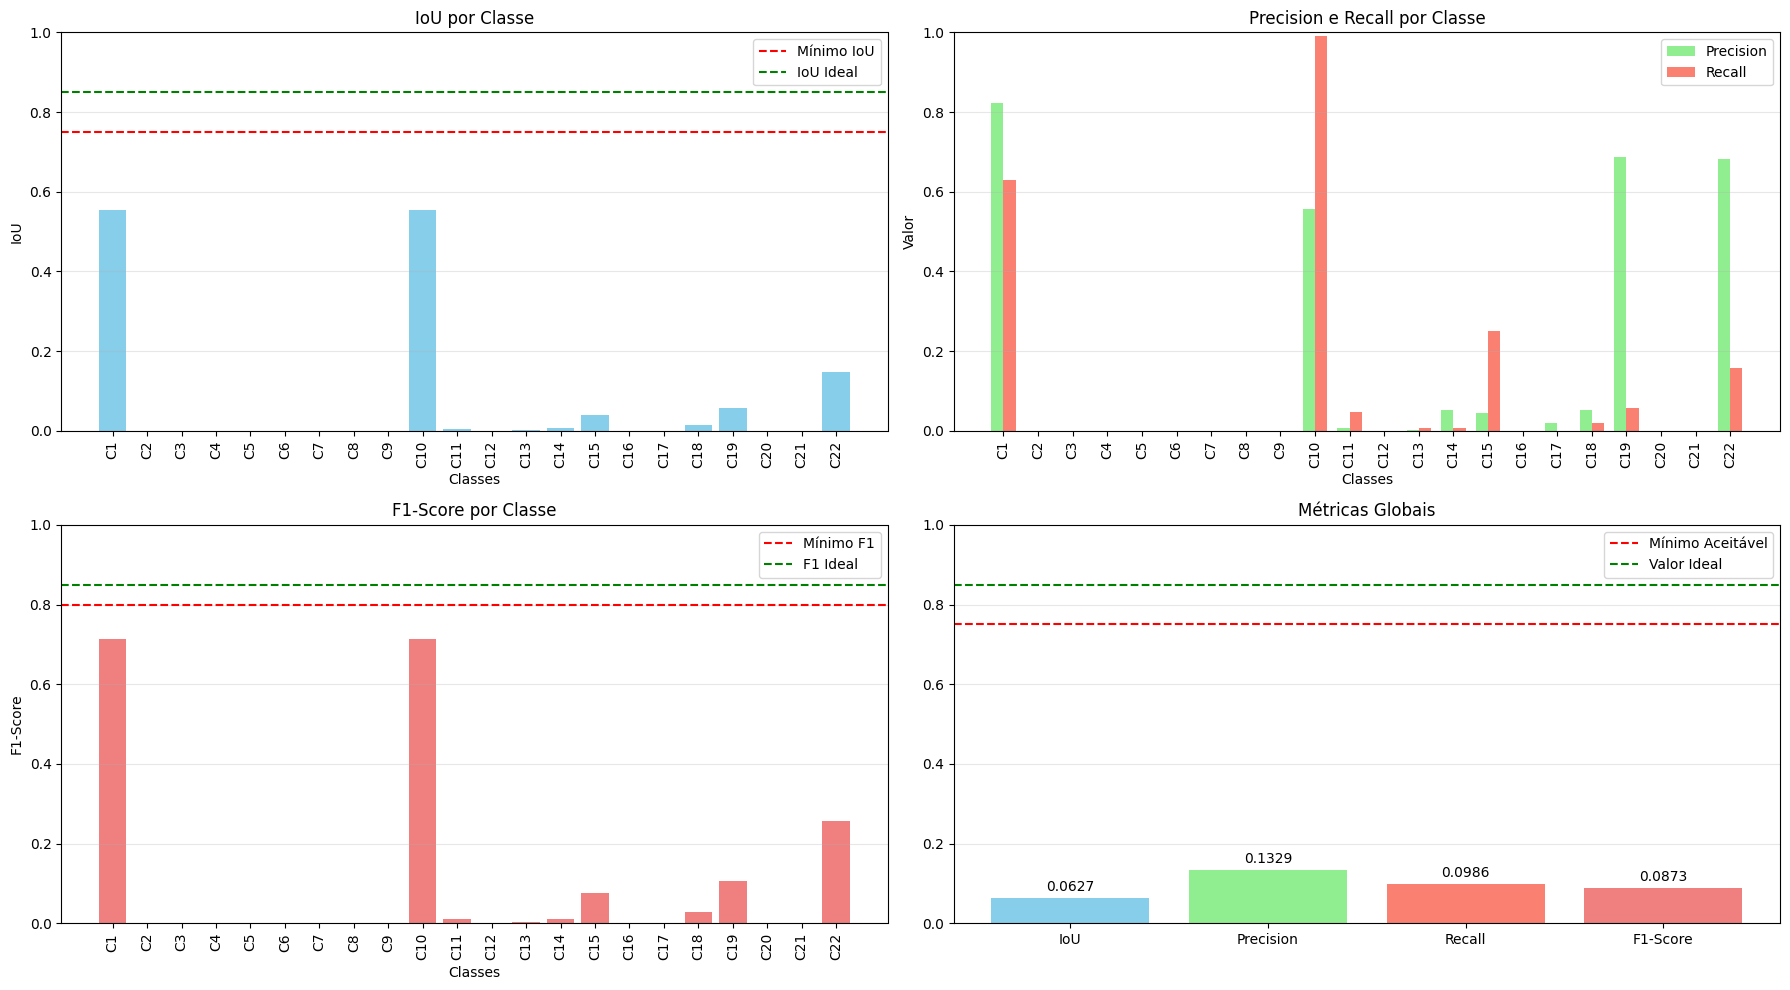


Resultados salvos em 'resultados_por_classe.csv' e 'metricas_globais.csv'


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pathlib
import os
from dotenv import load_dotenv
from sklearn.metrics import confusion_matrix

# Redefinir as funções necessárias para carregar o modelo treinado
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def multilabel_dice_loss(y_true, y_pred):
    loss = 0
    for i in range(y_pred.shape[-1]):
        loss += dice_loss(y_true[..., i], y_pred[..., i])
    return loss / y_pred.shape[-1]

def bce_dice_loss(y_true, y_pred, dice_weight=0.5):
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_true, y_pred)
    dice = multilabel_dice_loss(y_true, y_pred)
    return (1 - dice_weight) * bce + dice_weight * dice

def loss_function(y_true, y_pred):
    return bce_dice_loss(y_true, y_pred, dice_weight=0.5)

class MultilabelIoU(tf.keras.metrics.Metric):
    def __init__(self, num_classes=22, threshold=0.5, name='multiclass_iou', **kwargs):
        super(MultilabelIoU, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.threshold = threshold
        # Manter somas separadas para cada classe
        self.total_intersection = self.add_weight(
            name='total_intersection', 
            shape=(num_classes,),
            initializer='zeros')
        self.total_union = self.add_weight(
            name='total_union', 
            shape=(num_classes,),
            initializer='zeros')
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Binarizar previsões
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        
        # Calcular intersecção e união para todas as classes
        intersection = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2])
        union = tf.reduce_sum(y_true, axis=[0, 1, 2]) + tf.reduce_sum(y_pred, axis=[0, 1, 2]) - intersection
        
        # Acumular estatísticas por classe
        self.total_intersection.assign_add(intersection)
        self.total_union.assign_add(union)
        
    def result(self):
        # Calcular IoU para cada classe (evitando divisão por zero)
        iou = tf.where(
            self.total_union > 0, 
            self.total_intersection / (self.total_union + 1e-10),
            tf.zeros_like(self.total_union)  # Usar 0 para classes ausentes (não 1!)
        )
        
        # Calcular média apenas para classes que aparecem nos dados
        valid_classes = tf.cast(self.total_union > 0, tf.float32)
        num_valid_classes = tf.reduce_sum(valid_classes)
        
        mean_iou = tf.cond(
            num_valid_classes > 0,
            lambda: tf.reduce_sum(iou) / num_valid_classes,
            lambda: tf.constant(0.0)
        )
        
        return mean_iou
    
    def reset_state(self):
        self.total_intersection.assign(tf.zeros_like(self.total_intersection))
        self.total_union.assign(tf.zeros_like(self.total_union))

def load_test_dataset():
    """
    Carrega o conjunto de dados de teste
    """
    # Carregar variáveis de ambiente
    load_dotenv()
    
    img_dir_str = os.getenv("BASE_IMG_FOLDER")
    if img_dir_str is None:
        raise ValueError("A variável de ambiente BASE_IMG_FOLDER não está definida no arquivo .env")
    img_dir = pathlib.Path(img_dir_str)
    
    mask_dir_str = os.getenv("NUMPY_FOLDER")
    if mask_dir_str is None:
        raise ValueError("A variável de ambiente NUMPY_FOLDER não está definida no arquivo .env")
    mask_dir = pathlib.Path(mask_dir_str)
    
    # Funções para extrair número do arquivo
    def get_file_number(filepath):
        return int(os.path.basename(filepath).replace('.png', ''))
    
    def get_file_number_mask(filepath):
        return int(os.path.basename(filepath).replace('.npy', ''))
    
    # Listar arquivos
    mask_files = [str(path) for path in mask_dir.glob('*.npy') if os.path.exists(path)]
    image_files = [str(path) for path in img_dir.glob('*.png') if os.path.exists(path)]
    
    # Ordenar
    image_files = sorted(image_files, key=get_file_number)
    mask_files = sorted(mask_files, key=get_file_number_mask)
    
    def load_and_preprocess_image_mask(image_path, mask_path):
        try:
            # Carregar imagem
            img = tf.io.read_file(image_path)
            img = tf.image.decode_png(img, channels=3)
            img = tf.image.resize(img, [512, 512])
            img = tf.cast(img, tf.float32) / 255.0
            
            # Carregar máscara
            mask = np.load(mask_path.numpy().decode())
            mask = tf.convert_to_tensor(mask, dtype=tf.float32)
            mask = mask / 255.0
            mask = tf.where(mask >= 0.3, 1.0, 0.0)
            
            return img, mask
        except Exception as e:
            print(f"Erro ao processar {image_path}, {mask_path}: {str(e)}")
            raise
    
    def process_path(image_path, mask_path):
        img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
        img.set_shape((512, 512, 3))
        mask.set_shape((512, 512, 22))
        return img, mask
    
    # Criar dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Dividir dataset (mesma lógica do código original)
    dataset_size = tf.data.experimental.cardinality(dataset).numpy()
    train_size = int(0.8 * dataset_size)
    val_size = int(0.1 * dataset_size)
    
    # Dividir usando a mesma metodologia do treinamento
    shuffled_dataset = dataset.shuffle(buffer_size=32)
    train_dataset = shuffled_dataset.take(train_size)
    remaining_dataset = shuffled_dataset.skip(train_size)
    val_dataset = remaining_dataset.take(val_size)
    test_dataset = remaining_dataset.skip(val_size)
    
    # Configurar batch
    test_dataset = test_dataset.batch(8).prefetch(1)
    
    return test_dataset

def process_batch_metrics(y_true_batch, y_pred_batch, threshold=0.5, num_classes=22):
    """
    Processa métricas para um único batch
    Retorna IoU, Precision, Recall, F1 e contribuição para a matriz de confusão
    """
    
    # Para métricas por canal (TP, FP, FN, TN), pode usar o threshold
    y_pred_binary = tf.cast(y_pred_batch > threshold, tf.float32)
    
    # Arrays para armazenar resultados deste batch
    batch_tp = np.zeros(num_classes)
    batch_fp = np.zeros(num_classes)
    batch_fn = np.zeros(num_classes)
    batch_tn = np.zeros(num_classes)
    
    # Calcular métricas para cada classe
    for i in range(num_classes):
        y_true_class = y_true_batch[..., i]
        y_pred_class = y_pred_binary[..., i]
        
        # True Positives, False Positives, False Negatives, True Negatives
        tp = tf.reduce_sum(y_true_class * y_pred_class).numpy()
        fp = tf.reduce_sum((1 - y_true_class) * y_pred_class).numpy()
        fn = tf.reduce_sum(y_true_class * (1 - y_pred_class)).numpy()
        tn = tf.reduce_sum((1 - y_true_class) * (1 - y_pred_class)).numpy()
        
        batch_tp[i] = tp
        batch_fp[i] = fp
        batch_fn[i] = fn
        batch_tn[i] = tn

    # Para a matriz de confusão, é recomendável não usar threshold
    y_true_argmax = tf.argmax(y_true_batch, axis=-1).numpy().flatten()
    y_pred_argmax = tf.argmax(y_pred_batch, axis=-1).numpy().flatten()
    
    # Computar a matriz de confusão para este batch
    batch_cm = confusion_matrix(y_true_argmax, y_pred_argmax, labels=range(num_classes))
    
    return batch_tp, batch_fp, batch_fn, batch_tn, batch_cm

def calculate_final_metrics(total_tp, total_fp, total_fn, total_tn, num_classes):
    """
    Calcula métricas finais a partir dos totais acumulados
    """
    iou_per_class = np.zeros(num_classes)
    precision_per_class = np.zeros(num_classes)
    recall_per_class = np.zeros(num_classes)
    f1_per_class = np.zeros(num_classes)
    
    for i in range(num_classes):
        # IoU = TP / (TP + FP + FN)
        iou_per_class[i] = total_tp[i] / (total_tp[i] + total_fp[i] + total_fn[i] + 1e-10)
        
        # Precision = TP / (TP + FP)
        precision_per_class[i] = total_tp[i] / (total_tp[i] + total_fp[i] + 1e-10)
        
        # Recall = TP / (TP + FN)
        recall_per_class[i] = total_tp[i] / (total_tp[i] + total_fn[i] + 1e-10)
        
        # F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
        f1_per_class[i] = 2 * precision_per_class[i] * recall_per_class[i] / (precision_per_class[i] + recall_per_class[i] + 1e-10)
    
    return iou_per_class, precision_per_class, recall_per_class, f1_per_class

def plot_confusion_matrix(cm, class_names=None, figsize=(14, 12), cmap='Blues', save_path=None):
    """
    Plota a matriz de confusão
    """
    if class_names is None:
        class_names = [f'Classe {i+1}' for i in range(cm.shape[0])]
    
    plt.figure(figsize=figsize)
    
    # Normalizar para porcentagens por linha (classe verdadeira)
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
    
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.title('Matriz de Confusão (%)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

def evaluate_and_report(model_path='best_model_bce_dice_v3.keras', num_classes=22):
    """
    Função principal para avaliar o modelo e gerar relatório completo
    Versão modificada para processar incrementalmente (evitar OOM)
    """
    # Definir nomes das classes (substitua pelos nomes reais se disponíveis)
    class_names = [f'Classe_{i+1}' for i in range(num_classes)]
    
    # Verificar se o modelo existe
    if not os.path.exists(model_path):
        raise ValueError(f"Modelo não encontrado: {model_path}")
    
    # Carregar modelo
    print(f"Carregando modelo de {model_path}...")
    custom_objects = {
        'loss_function': loss_function,
        'MulticlassIoU': MultilabelIoU,
        'dice_coef': dice_coef,
        'dice_loss': dice_loss,
        'multilabel_dice_loss': multilabel_dice_loss
    }
    
    model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    
    # Carregar conjunto de teste
    print("Carregando conjunto de dados de teste...")
    test_dataset = load_test_dataset()
    
    # Avaliar modelo com métricas padrão
    print("\nAvaliando modelo no conjunto de teste...")
    test_loss, test_acc, test_iou, test_precision, test_recall = model.evaluate(test_dataset, verbose=1)
    
    print("\n===== Métricas Gerais =====")
    print(f"Loss: {test_loss:.4f}")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Mean IoU: {test_iou:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    
    # Inicializar contadores para todas as classes
    total_tp = np.zeros(num_classes)
    total_fp = np.zeros(num_classes)
    total_fn = np.zeros(num_classes)
    total_tn = np.zeros(num_classes)
    
    # Inicializar matriz de confusão
    total_cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    
    # Processar batch por batch para evitar OOM
    print("\nProcessando métricas detalhadas incrementalmente...")
    batch_count = 0
    
    for images, masks in test_dataset:
        batch_count += 1
        print(f"Processando batch {batch_count}...")
        
        # Fazer previsões para este batch
        predictions = model.predict(images, verbose=0)
        
        # Processar métricas para este batch
        batch_tp, batch_fp, batch_fn, batch_tn, batch_cm = process_batch_metrics(
            masks, predictions, threshold=0.5, num_classes=num_classes
        )
        
        # Acumular resultados
        total_tp += batch_tp
        total_fp += batch_fp
        total_fn += batch_fn
        total_tn += batch_tn
        total_cm += batch_cm
    
    # Calcular métricas finais a partir dos valores acumulados
    iou_per_class, precision_per_class, recall_per_class, f1_per_class = calculate_final_metrics(
        total_tp, total_fp, total_fn, total_tn, num_classes
    )
    
    # Calcular médias globais
    global_iou = np.mean(iou_per_class)
    global_f1 = np.mean(f1_per_class)
    global_precision = np.mean(precision_per_class)
    global_recall = np.mean(recall_per_class)
    
    # Criar DataFrame de resultados
    results_df = pd.DataFrame({
        'Classe': class_names,
        'IoU': iou_per_class,
        'Precision': precision_per_class,
        'Recall': recall_per_class,
        'F1-Score': f1_per_class
    })
    
    # Mostrar métricas globais (importantes para o artigo)
    print("\n===== Métricas Globais para o Artigo =====")
    print(f"IoU Global Médio: {global_iou:.4f}")
    print(f"F1-Score Global: {global_f1:.4f}")
    print(f"Precision Global: {global_precision:.4f}")
    print(f"Recall Global: {global_recall:.4f}")
    
    # Verificar se atende aos requisitos mínimos
    print("\n===== Verificação de Requisitos Mínimos =====")
    print(f"IoU Global Médio: {global_iou:.4f} (Mínimo aceitável: 0.75, Ideal: >0.85)")
    if global_iou >= 0.85:
        print("✅ IoU Global IDEAL alcançado!")
    elif global_iou >= 0.75:
        print("✅ IoU Global ACEITÁVEL alcançado")
    else:
        print("❌ IoU Global ABAIXO do mínimo aceitável")
    
    print(f"F1-Score Global: {global_f1:.4f} (Mínimo aceitável: 0.80, Ideal: >0.85)")
    if global_f1 >= 0.85:
        print("✅ F1-Score Global IDEAL alcançado!")
    elif global_f1 >= 0.80:
        print("✅ F1-Score Global ACEITÁVEL alcançado")
    else:
        print("❌ F1-Score Global ABAIXO do mínimo aceitável")
    
    # Ordenar classes por IoU para identificar as mais desafiadoras
    results_sorted = results_df.sort_values('IoU')
    
    print("\n===== Métricas por Classe =====")
    print(results_df.to_string(index=False))
    
    print("\n===== Classes Mais Desafiadoras (Menor IoU) =====")
    print(results_sorted.head(5).to_string(index=False))
    
    # Gerar matriz de confusão
    print("\nGerando matriz de confusão...")
    plot_confusion_matrix(total_cm, class_names, save_path='confusion_matrix.png')
    
    # Visualizar métricas por classe em gráficos
    print("\nGerando visualizações das métricas por classe...")
    plt.figure(figsize=(18, 10))
    
    # IoU por classe
    plt.subplot(2, 2, 1)
    bars = plt.bar(range(len(class_names)), iou_per_class, color='skyblue')
    plt.axhline(y=0.75, color='r', linestyle='--', label='Mínimo IoU')
    plt.axhline(y=0.85, color='g', linestyle='--', label='IoU Ideal')
    plt.title('IoU por Classe')
    plt.xlabel('Classes')
    plt.ylabel('IoU')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(range(len(class_names)), [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # Precisão e Recall por classe
    plt.subplot(2, 2, 2)
    width = 0.35
    x = np.arange(len(class_names))
    plt.bar(x - width/2, precision_per_class, width, label='Precision', color='lightgreen')
    plt.bar(x + width/2, recall_per_class, width, label='Recall', color='salmon')
    plt.title('Precision e Recall por Classe')
    plt.xlabel('Classes')
    plt.ylabel('Valor')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(x, [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # F1-Score por classe
    plt.subplot(2, 2, 3)
    bars = plt.bar(range(len(class_names)), f1_per_class, color='lightcoral')
    plt.axhline(y=0.80, color='r', linestyle='--', label='Mínimo F1')
    plt.axhline(y=0.85, color='g', linestyle='--', label='F1 Ideal')
    plt.title('F1-Score por Classe')
    plt.xlabel('Classes')
    plt.ylabel('F1-Score')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(range(len(class_names)), [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # Métricas globais resumidas
    plt.subplot(2, 2, 4)
    global_metrics = [global_iou, global_precision, global_recall, global_f1]
    metric_names = ['IoU', 'Precision', 'Recall', 'F1-Score']
    bars = plt.bar(metric_names, global_metrics, color=['skyblue', 'lightgreen', 'salmon', 'lightcoral'])
    
    # Adicionar linhas de requisitos para IoU e F1
    plt.axhline(y=0.75, color='r', linestyle='--', label='Mínimo Aceitável')
    plt.axhline(y=0.85, color='g', linestyle='--', label='Valor Ideal')
    
    plt.title('Métricas Globais')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    
    # Adicionar valores acima das barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('metricas_segmentacao.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Salvar resultados em CSV para inclusão no artigo
    results_df.to_csv('resultados_por_classe.csv', index=False)
    
    # Criar tabela de métricas globais para o artigo
    global_metrics_df = pd.DataFrame({
        'Métrica': ['IoU Global', 'F1-Score Global', 'Precision Global', 'Recall Global'],
        'Valor': [global_iou, global_f1, global_precision, global_recall],
        'Requisito Mínimo': ['0.75', '0.80', 'N/A', 'N/A'],
        'Valor Ideal': ['0.85', '0.85', 'N/A', 'N/A'],
        'Status': [
            '✅ IDEAL' if global_iou >= 0.85 else '✅ ACEITÁVEL' if global_iou >= 0.75 else '❌ ABAIXO',
            '✅ IDEAL' if global_f1 >= 0.85 else '✅ ACEITÁVEL' if global_f1 >= 0.80 else '❌ ABAIXO',
            'N/A', 'N/A'
        ]
    })
    
    global_metrics_df.to_csv('metricas_globais.csv', index=False)
    print("\nResultados salvos em 'resultados_por_classe.csv' e 'metricas_globais.csv'")
    
    return global_metrics_df, results_df

# Executar a avaliação
if __name__ == "__main__":
    evaluate_and_report()